In [22]:
import numpy as np
import time
import matplotlib.pyplot as plt

## Chapter 01b — Vectorization & Broadcasting

This is where NumPy earns its keep. The theme of this whole notebook:

> **Turn an equation directly into array code.**

If a formula says "do this to every entry", you do **not** write a loop — you
write the formula once and NumPy applies it to the entire array at once. This is
called **vectorization**. It is shorter, reads like math, and runs *much* faster.

___
### 1. Elementwise arithmetic

Arithmetic on arrays happens **elementwise**: `u + v` adds matching entries,
`u * v` multiplies matching entries, and so on. This is exactly vector addition
and scalar multiplication from linear algebra.

In [23]:
u = np.array([1, 2, 3])
v = np.array([10, 20, 30])

print(u + v)     # [11 22 33]   entry by entry
print(v - u)     # [ 9 18 27]
print(u * v)     # [10 40 90]   elementwise product (NOT the dot product)
print(u / v)
print(v / u)     # [10. 10. 10.]
print(u ** 2)    # [1 4 9]      square every entry

[11 22 33]
[ 9 18 27]
[10 40 90]
[0.1 0.1 0.1]
[10. 10. 10.]
[1 4 9]


In [24]:
# A scalar applies to every entry (this is "broadcasting", section 4):
print(3 * u)     # [3 6 9]   scalar multiple of a vector
print(u + 100)   # [101 102 103]

[3 6 9]
[101 102 103]


____
## 2. Universal functions (ufuncs): math on whole arrays

NumPy ships fast, elementwise versions of the usual math functions. They are
called **ufuncs**. Feed in an array, get back an array of the same shape.

$\sin,\ \cos,\ \exp,\ \log,\ \sqrt,\ \dots$ all work this way.

In [25]:
import numpy as np

x = np.array([0.0, 1.0, 4.0, 9.0])

print(np.sqrt(x))   # [0. 1. 2. 3.]    square root of each entry
print(np.exp(x))    # e^x for each entry
print(np.log1p(x))  # log(1+x), safe near 0

[0. 1. 2. 3.]
[1.00000000e+00 2.71828183e+00 5.45981500e+01 8.10308393e+03]
[0.         0.69314718 1.60943791 2.30258509]


In [26]:
angles = np.array([0, np.pi / 6, np.pi / 4, np.pi / 2])
print(np.sin(angles))
print(np.cos(angles))

[0.         0.5        0.70710678 1.        ]
[1.00000000e+00 8.66025404e-01 7.07106781e-01 6.12323400e-17]


**Turning an equation into code.** Suppose $g(x) = \sqrt{x}\,e^{-x}$. On paper
that's one line; in NumPy it is also one line, and it works on a whole array of
$x$ values simultaneously:

In [27]:
x = np.linspace(0, 4, 9)         # nine x-values
g = np.sqrt(x) * np.exp(-x)      # the formula, applied to ALL of them at once
for xi, gi in zip(x, g):
    print(f"g({xi:.1f}) = {gi:.4f}")

g(0.0) = 0.0000
g(0.5) = 0.4289
g(1.0) = 0.3679
g(1.5) = 0.2733
g(2.0) = 0.1914
g(2.5) = 0.1298
g(3.0) = 0.0862
g(3.5) = 0.0565
g(4.0) = 0.0366


___
### 3. Vectorization vs. Python loops (and why speed matters)

The same computation can be done with a slow Python loop or with one vectorized
expression. Let's check they agree, then time them.

In [28]:
N = 1_000_000
x = np.linspace(0, 10, N)

# Time the loop
t0 = time.perf_counter()
y_loop = np.empty(N)
for i in range(N):
    y_loop[i] = np.sin(x[i]) ** 2
t1 = time.perf_counter()

# Time the vectorized version
t2 = time.perf_counter()
y_vec = np.sin(x) ** 2
t3 = time.perf_counter()

loop_time = t1 - t0
vec_time = t3 - t2
print(f"loop       : {loop_time:.4f} s")
print(f"vectorized : {vec_time:.4f} s")
print(f"speedup    : about {loop_time / vec_time:.0f}x faster")

loop       : 1.9896 s
vectorized : 0.0135 s
speedup    : about 148x faster


The vectorized version is typically **tens to hundreds of times faster** — and
shorter to write. The lesson: *if you find yourself writing a `for` loop over the
entries of an array, look for the vectorized expression instead.*

____
### 4. Broadcasting: combining different shapes

What if shapes don't match? NumPy **broadcasts**: it stretches the smaller array
across the larger one when their shapes are compatible. You already saw the
simplest case, `3 * u`, where the scalar `3` was applied to every entry.

**The rule (read shapes from the right):** two dimensions are compatible when
they are **equal**, or **one of them is 1**. A size-1 (or missing) dimension is
stretched to match.

In [29]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])      # shape (2, 3)
row = np.array([10, 20, 30])   # shape (3,)

# 'row' is stretched down to both rows of A:
print(A + row)
# [[11 22 33]
#  [14 25 36]]

col = np.array([[100],
                [200]])            # shape (2, 1)

# 'col' is stretched across the three columns:
print(A + col)
# [[101 102 103]
#  [204 205 206]]

[[11 22 33]
 [14 25 36]]
[[101 102 103]
 [204 205 206]]


A classic use: build a **multiplication table** (an outer product) by combining a
column vector and a row vector. The $(i,j)$ entry becomes $i \cdot j$.

In [30]:
i = np.arange(1, 6).reshape(5, 1)
j = np.arange(1, 6).reshape(1, 5)

table = i * j
print(table)

[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]


___
### 5. Reductions: collapsing an array to a summary

A **reduction** boils an array down to fewer numbers: `sum`, `mean`, `std`
(standard deviation), `min`, `max`. With no `axis`, it uses the whole array.

In [31]:
x = np.array([2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0])
print("sum  :", x.sum())
print("mean :", x.mean())
print("std  :", x.std())     # population standard deviation
print("min  :", x.min(), " max :", x.max())

sum  : 40.0
mean : 5.0
std  : 2.0
min  : 2.0  max : 9.0


Std tells you how spread out the numbers in an array are around their mean (average).

* Small std → values are clustered together.

* Large std → values are spread out.

https://chatgpt.com/s/w_6ab5012969248191815fd37a988f881b

___
For a 2D array, `axis` chooses the direction to collapse:

- `axis=0` collapses **down the rows** → one value per **column**.
- `axis=1` collapses **across the columns** → one value per **row**.

In [32]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])      # shape (2, 3)

print("total          :", A.sum())          # 21  (everything)
print("column sums    :", A.sum(axis=0))    # [5 7 9]   (down the rows)
print("row sums       :", A.sum(axis=1))    # [ 6 15]   (across the columns)
print("column means   :", A.mean(axis=0))   # [2.5 3.5 4.5] -> (1 + 4)/2 etc

total          : 21
column sums    : [5 7 9]
row sums       : [ 6 15]
column means   : [2.5 3.5 4.5]


____
### 6. The payoff: an equation becomes a plot

Now we combine everything. To plot $f(x) = \sin(x)$ on $[0, 2\pi]$ we make a fine
grid with `linspace`, apply the ufunc `np.sin` to the whole grid, and plot. No
loops anywhere — the code reads like the math.

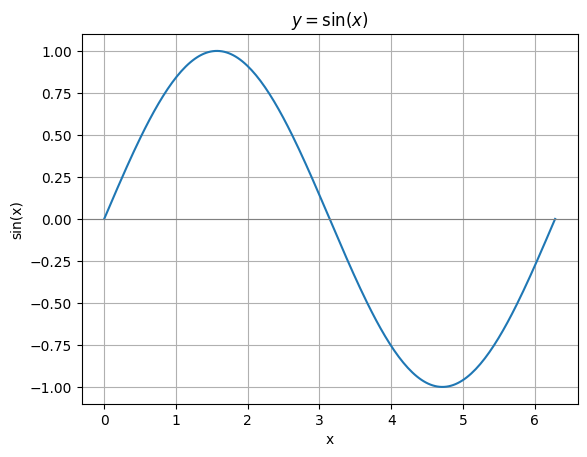

In [34]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

plt.plot(x, y)
plt.title(r"$y = \sin(x)$")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.grid(True)
plt.show()

Compare this to the list-and-loop version from Chapter 00b. Same picture, far
less code — and it generalizes: swap `np.sin` for any ufunc and you instantly
plot a different function.